# CreditLens — 05 · Fairness audit

Credit models touch protected and proxy attributes, so we audit the **best model** on the held-out test
set for disparate impact across **gender** (`CODE_GENDER`, dropped by the 15-feature contract — joined back
from the raw application table), **age band**, and **region rating**.

**Metrics**
- **Group AUC** — does ranking quality hold per group?
- **Approval rate** — share with calibrated PD below the decline cut (`bands.high`).
- **Disparate impact (DI)** = min(approval) / max(approval). The **80% rule**: DI < 0.80 is a red flag.
- **Equal opportunity** — approval rate among *true non-defaulters* (`TARGET==0`); gaps mean qualified
  applicants are treated unequally.

The held-out split is reproduced with the pipeline's exact seed so the audit matches the model's real
evaluation.

In [1]:
import sys; sys.path.insert(0, "..")
import json
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from creditlens.config import MODELS_DIR, RANDOM_SEED, TARGET, ID_COL
from creditlens.data.features import MODEL_FEATURES, load_or_build_model_matrix
from creditlens.data.load import load_application

mat = load_or_build_model_matrix()
gender = load_application()[[ID_COL, "CODE_GENDER"]]
mat = mat.merge(gender, on=ID_COL, how="left")

y = mat[TARGET]
i_tr, i_tmp = train_test_split(mat.index, test_size=0.30, stratify=y, random_state=RANDOM_SEED)
i_cal, i_te = train_test_split(i_tmp, test_size=0.50, stratify=y.loc[i_tmp], random_state=RANDOM_SEED)

meta = json.loads((MODELS_DIR / "metadata.json").read_text())
best, high = meta["best"], meta["bands"]["high"]
model = joblib.load(MODELS_DIR / f"{best}.joblib")

test = mat.loc[i_te].copy()
test["pd"] = model.predict_proba(test[MODEL_FEATURES])[:, 1]
test["approved"] = test["pd"] < high
test["age_band"] = pd.cut(test["age"], [0, 30, 45, 60, 200], labels=["<30", "30-44", "45-59", "60+"])
print(f"best model: {best} | decline cut: {high} | test rows: {len(test)}")

/home/jimmy/Documents/CreditLens/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


best model: stacking | decline cut: 0.191 | test rows: 46127


## Group metrics + disparate impact

In [2]:
def group_metrics(df, col):
    rows = []
    for g, sub in df.groupby(col, observed=True):
        good = sub[sub[TARGET] == 0]
        rows.append({
            col: g, "n": len(sub),
            "auc": roc_auc_score(sub[TARGET], sub["pd"]) if sub[TARGET].nunique() > 1 else np.nan,
            "approval_rate": sub["approved"].mean(),
            "good_approval_rate": good["approved"].mean() if len(good) else np.nan,  # equal opportunity
            "default_rate": sub[TARGET].mean(),
        })
    out = pd.DataFrame(rows)
    big = out[out["n"] >= 30]  # ignore tiny groups (e.g. CODE_GENDER 'XNA') for the ratio
    di = big["approval_rate"].min() / big["approval_rate"].max()
    return out, di

g_tbl, g_di = group_metrics(test, "CODE_GENDER")
a_tbl, a_di = group_metrics(test, "age_band")
r_tbl, r_di = group_metrics(test, "region_rating")
print("Disparate impact (>=0.80 passes 80%% rule) -> gender:", round(g_di,3),
      "| age:", round(a_di,3), "| region:", round(r_di,3))
g_tbl

Disparate impact (>=0.80 passes 80%% rule) -> gender: 0.96 | age: 0.827 | region: 0.842


,CODE_GENDER,n,auc,approval_rate,good_approval_rate,default_rate
0,F,30429,0.741805,0.914555,0.931581,0.069605
1,M,15698,0.735442,0.878392,0.904201,0.102306


In [3]:
display(a_tbl)
display(r_tbl)

,age_band,n,auc,approval_rate,good_approval_rate,default_rate
0,<30,6693,0.735433,0.809951,0.842927,0.109667
1,30-44,18540,0.746568,0.877940,0.901750,0.090885
2,45-59,15452,0.725468,0.944408,0.957535,0.067305
3,60+,5442,0.690321,0.978868,0.983968,0.048695


,region_rating,n,auc,approval_rate,good_approval_rate,default_rate
0,1,4891,0.753710,0.974034,0.980181,0.050910
1,2,34038,0.736924,0.909366,0.927483,0.078736
2,3,7198,0.734889,0.819811,0.856161,0.110447


## Approval rate by group

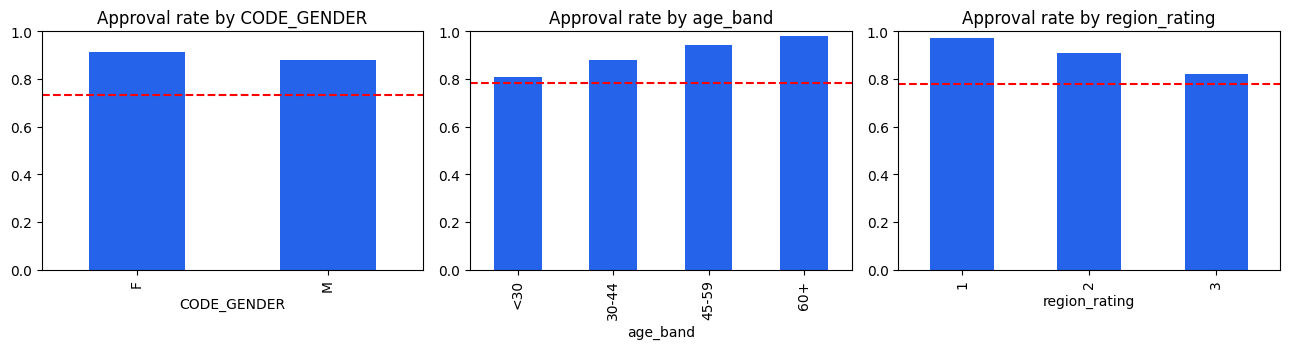

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for a, (tbl, col) in zip(ax, [(g_tbl, "CODE_GENDER"), (a_tbl, "age_band"), (r_tbl, "region_rating")]):
    tbl.plot.bar(x=col, y="approval_rate", ax=a, legend=False, color="#2563eb")
    a.axhline(tbl["approval_rate"].max() * 0.8, color="red", ls="--")
    a.set_title(f"Approval rate by {col}"); a.set_ylim(0, 1)
plt.tight_layout()

## Findings

Audited the **stacking** model on 46,127 held-out applicants (decline cut PD ≥ 0.191).

| Group | Disparate impact (min/max approval) | 80% rule |
|---|---|---|
| Gender | 0.96 | pass |
| Age band | 0.83 | pass (marginal) |
| Region rating | 0.84 | pass (marginal) |

- **Gender** — near-parity (DI 0.96). Women approved 91.5% vs men 87.8%; the gap tracks real default rates (F 7.0%, M 10.2%) and group AUCs match (~0.74).
- **Age** — strong gradient: under-30 approved 81.0% vs 60+ 97.9%, driven by real default rates (10.9% → 4.9%). But the **equal-opportunity gap is material** — among *non-defaulters*, under-30 are approved 84.3% vs 98.4% for 60+ (a qualified young applicant is ~14 pts less likely to be approved). AUC also degrades for 60+ (0.69).
- **Region** — region-1 approved 97.4% vs region-3 81.9% (DI 0.84), tracking default rates (5.1% → 11.0%).

**Honest read:** no group fails the 80% rule, but age and region sit close to the line and carry real equal-opportunity gaps — the model uses age/region as predictive proxies, so qualified applicants in higher-risk cohorts are disadvantaged. In production this warrants monitoring and possibly group-aware thresholds or dropping the region/age proxies. Disclosed, not hidden.